In [ ]:
import sys
import networkx as nx
import osmnx as ox
import rasterio
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter

#NOTE by default OSM doesnt call the bicycle and cycleway info for performance reasons  
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["bicycle", "cycleway"]

bike


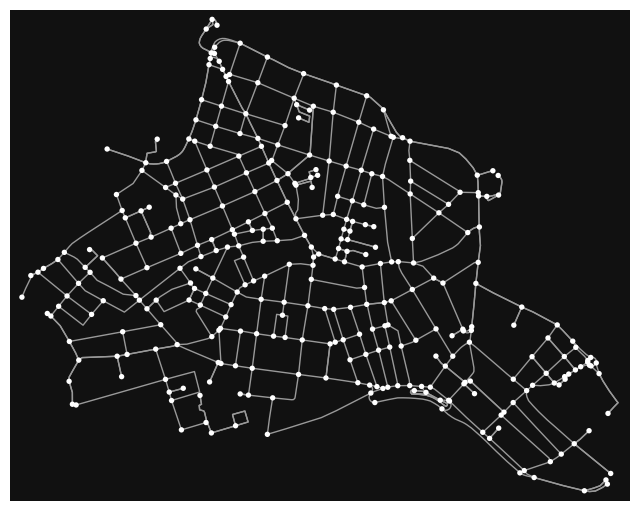

drive


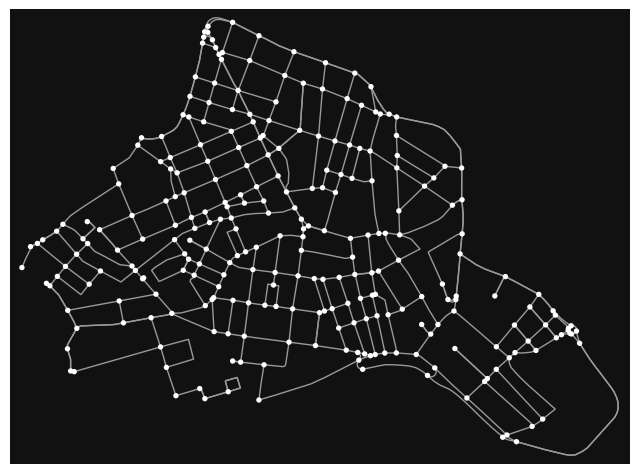

In [3]:
print("bike")

# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="bike")
fig, ax = ox.plot.plot_graph(G)

print("drive")
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

OSM Highway Tags Reference


Motor Vehicle Roads


- residential (26,195) - Streets in residential areas, usually low speed
- unclassified (6,501) - Minor public roads, often rural or local streets
- tertiary (5,268) - Important local roads connecting towns/villages
- secondary (4,327) - Regional roads connecting cities/large towns
- primary (1,624) - Major roads between cities, often dual carriageway
- trunk (1,378) - Major highways, national importance roads


Service & Access Roads
- service (15,417) - Service roads (parking lots, driveways, alleys)
- trunk_link (209) - Connecting ramps to trunk roads
- secondary_link (65) - Connecting ramps to secondary roads
- tertiary_link (43) - Connecting ramps to tertiary roads
- primary_link (39) - Connecting ramps to primary roads


Pedestrian & Cycling Infrastructure
- track (11,050) - Tracks for agriculture/forestry, often unpaved
- path (2,408) - Generic paths for walking/cycling
- living_street (1,040) - Shared space streets (pedestrians have priority)
- pedestrian (564) - Pedestrian-only areas/streets
- cycleway (282) - Dedicated bicycle infrastructure


Public Transport
- busway (1) - Dedicated bus lanes/roads


Road Hierarchy (Malta context)
- Trunk → Main highways
- Primary → Major arterial roads
- Secondary → Important regional roads
- Tertiary → Local connector roads
- Unclassified → Minor local roads
- Residential → Neighborhood streets

footway: 9918  #not required since If bicycles are allowed as well, you can indicate this by adding a bicycle=yes tag.


path: 2852 # Not required since, highway=cycleway for one also usable by cyclists,


pedestrian: 635? # No since bike cant directly access unless explicitly stated.


steps: 1020


corridor: 10

highway ['trunk', 'trunk_link']
highway ['trunk', 'trunk_link']
highway ['trunk', 'trunk_link']
highway ['unclassified', 'track']
highway ['unclassified', 'service']
highway ['unclassified', 'path', 'track']
highway ['unclassified', 'track']
highway ['unclassified', 'track']
highway ['unclassified', 'service']
highway ['tertiary', 'service']
highway ['residential', 'service']
highway ['path', 'residential']
highway ['track', 'service']
highway ['living_street', 'path']
highway ['path', 'track']
highway ['unclassified', 'track']
highway ['unclassified', 'track']
highway ['path', 'track']
highway ['pedestrian', 'residential']
highway ['unclassified', 'track']
highway ['track', 'service']
highway ['track', 'residential']
highway ['pedestrian', 'residential']
highway ['track', 'residential']
highway ['unclassified', 'track']
highway ['trunk', 'trunk_link']
highway ['path', 'service']
highway ['residential', 'service']
highway ['pedestrian', 'residential']
highway ['pedestrian', 'residentia

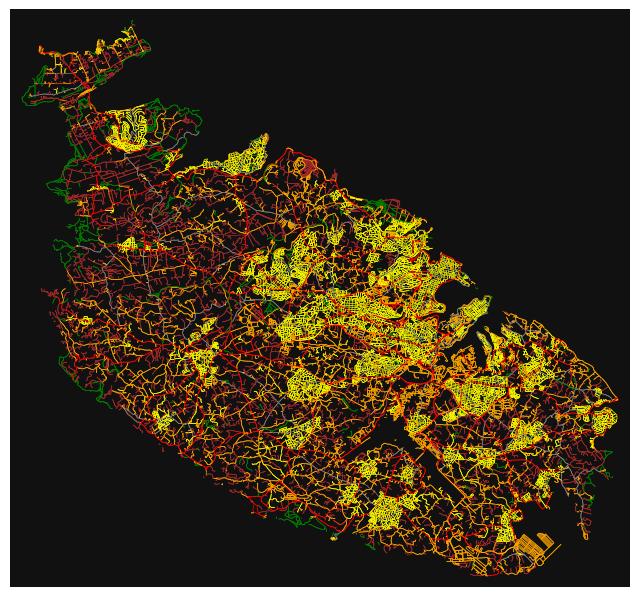

In [4]:
#TODO remove tracks from the network

#NOTE  retain_all to get all nodes even if not connected to the main network
G = ox.graph.graph_from_place("Malta (island)", network_type="bike", simplify=True, retain_all=True)
#fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

highway_color_map = {
    # SAFEST - Dedicated cycling infrastructure
    "cycleway": "green",        # Dedicated bike paths - safest
    "path": "green",           # Shared paths - generally safe
    
    # MODERATE - Cyclist-friendly streets  
    "living_street": "yellow",   # Shared space, pedestrian priority
    "residential": "yellow",        # Low speed, low traffic
    "pedestrian": "yellow",         # Walk/bike only areas

    
    # CAUTION - Mixed traffic but manageable
    "unclassified": "orange",  # Rural/local roads - variable safety
    "service": "orange",         # Parking lots, alleys - usually low speed
    #"track": "orange",            # Unpaved - may not be suitable

    # Dangerous
    "trunk":"red",
    "secondary":"red",
    "primary": "red",
    "trunk_link": "red",
    "secondary_link": "red",
    "tertiary_link": "red",
    "primary_link": "red",

    #Not suitable for urban transport / Development
    "track": "brown",
}



# Get the color for each edge based on its 'highway' attribute
edge_colors = []
highway_counts = Counter()
bikeway_counts = Counter()
cycleway_counts = Counter()
for u, v, k, data in G.edges(keys=True, data=True):
    once = False

    highway = data.get("highway")
    # Some edges may have a list of highway types
    if isinstance(highway, list): 
        print(f"highway {highway}")
        highway = highway[0]

    bicycle = data.get("bicycle")
    # Some edges may have a list of highway types
    if isinstance(bicycle, list):
        print(f"bicycle: {bicycle}")
        bicycle = bicycle[0]

    cycleway = data.get("cycleway")
    # Some edges may have a list of highway types
    if isinstance(cycleway, list): 
        print(f"cycleway: {cycleway}")
        cycleway = cycleway[0]

    # Override dangerous roads if bicycle=yes,
    # example kappara junction there is protected cycle lane on the main road 
    match(bicycle):
        case "designated": colour = "green"
        case "yes": colour = "green"
        case _: color = highway_color_map.get(highway, "gray") 
    edge_colors.append(color)

    highway_counts[highway] += 1
    bikeway_counts[bicycle] += 1
    cycleway_counts[cycleway] += 1

print("Highway type counts:")
for highway_type, count in highway_counts.most_common():
    print(f"{highway_type}: {count}")

print("-------")
print("bikeway classification type counts:")
for bikeway_type, count in bikeway_counts.most_common():
    print(f"{bikeway_type}: {count}")

print("------")
print("cycleway type counts:")
for cycleway_type, count in cycleway_counts.most_common():
    print(f"{cycleway_type}: {count}")


fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors, edge_linewidth=0.5)

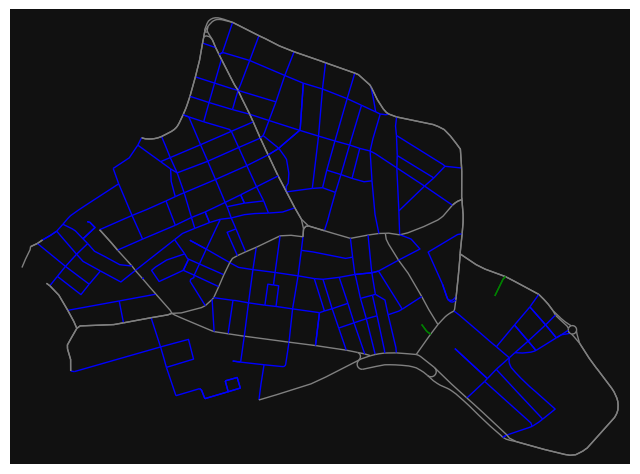

In [5]:
cycleways = '["cycleway"~"lane|track|share_busway|shared_lane"]' # cycleway = infrastructure type (physical/painted features)
highways = '["highway"~"residential|living_street|pedestrian|footway|cycleway"]'

#NOTE There is only 1 cycleway street
#TODO SPEED LIMIT TAG
#TODO painted lane like kapara junction

#bicycles = '["bicycle"!~"no"]' # bicycle = legal access (permission/prohibition), if there is not a tag there is implied service
bicycles = '["bicycle"~"yes|designated"]'
access = '["access"!~"private"]'

cf = f'{bicycles}{access}'

#NOTE Malta (island) vs Malta to exclude Gozo and Comino

G_drive = ox.graph.graph_from_place("Sliema, Malta", network_type="drive")
G_cycle = ox.graph.graph_from_place("Sliema, Malta", custom_filter=cf)

G = nx.compose(G_drive,G_cycle)
    
highway_color_map = {
    "residential":"blue",
    "living_street": "green",
    "pedestrian": "orange",
    "footway": "purple",
    "cycleway": "red"
}

# Get the color for each edge based on its 'highway' attribute
edge_colors = []
for u, v, k, data in G.edges(keys=True, data=True):
    highway = data.get("highway")
    # Some edges may have a list of highway types; handle that
    if isinstance(highway, list):
        highway = highway[0]
    color = highway_color_map.get(highway, "gray")  # default to gray if not found
    edge_colors.append(color)

fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors)

In [6]:
# Look at a few nodes and their attributes
print("Sample nodes:")
for i, (node_id, node_data) in enumerate(G_cycle.nodes(data=True)):
    if i < 3:  # Show first 3 nodes
        print(f"Node {node_id}: {node_data}")

# Look at a few edges and their attributes
print("Sample edges:")
for i, (u, v, k, edge_data) in enumerate(G_cycle.edges(keys=True, data=True)):
    if i < 5:  # Show first 5 edges
        print(f"Edge {u} -> {v} (key: {k}): {edge_data}")

# Find all unique edge attributes
all_edge_attrs = set()
for u, v, k, data in G_cycle.edges(keys=True, data=True):
    all_edge_attrs.update(data.keys())

print("Available edge attributes:")
for attr in sorted(all_edge_attrs):
    print(f"  - {attr}")

# Find all unique node attributes
all_node_attrs = set()
for node_id, data in G_cycle.nodes(data=True):
    all_node_attrs.update(data.keys())

print("\nAvailable node attributes:")
for attr in sorted(all_node_attrs):
    print(f"  - {attr}")

Sample nodes:
Node 146889143: {'y': 35.9087375, 'x': 14.4944756, 'street_count': 1}
Sample edges:
Available edge attributes:

Available node attributes:
  - street_count
  - x
  - y


# Topology


In [7]:
"""raster_path = "../Data/ebk1km1.tif"
G = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)
G = ox.elevation.add_edge_grades(G, add_absolute=True)"""

'raster_path = "../Data/ebk1km1.tif"\nG = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)\nG = ox.elevation.add_edge_grades(G, add_absolute=True)'

DEM info:
Bounds: BoundingBox(left=14.303194433333346, bottom=35.78736112222222, right=14.632916655555567, top=36.00458334444444)
Resolution: (0.0002777777777777778, 0.0002777777777777778)
CRS: EPSG:4326


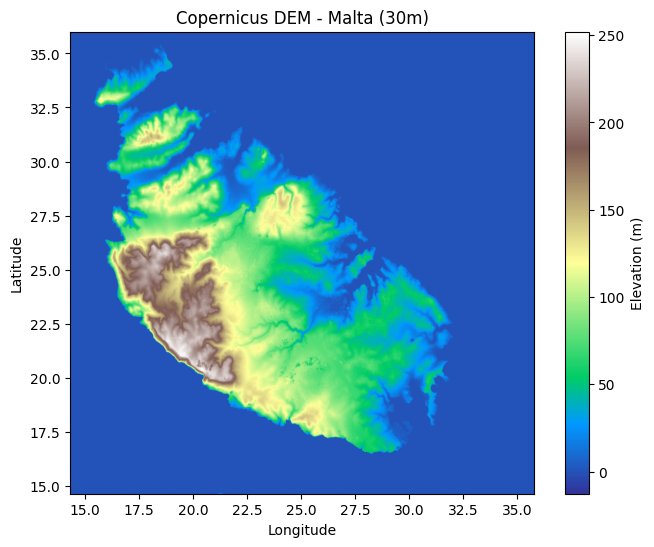

In [5]:
# path to your Copernicus DEM GeoTIFF
raster_path = "../Data/rasters_COP30.tif"

# open the raster
raster = rasterio.open(raster_path)

# print metadata to verify
print("DEM info:")
print(f"Bounds: {raster.bounds}")
print(f"Resolution: {raster.res}")
print(f"CRS: {raster.crs}")

# read the first (and only) band
elevation = raster.read(1)

# mask no-data values (these appear as very low or high numbers)
elevation = elevation.astype(float)
elevation[elevation <= -100] = float('nan')

# plot
plt.figure(figsize=(8, 6))
plt.imshow(elevation, cmap="terrain", extent=raster.bounds)
plt.colorbar(label="Elevation (m)")
plt.title("Copernicus DEM - Malta (30m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


DEM info:
Bounds: BoundingBox(left=4713630.0, bottom=1427140.0, right=4739700.0, top=1450030.0)
Resolution: (30.0, 30.0)
CRS: EPSG:3035


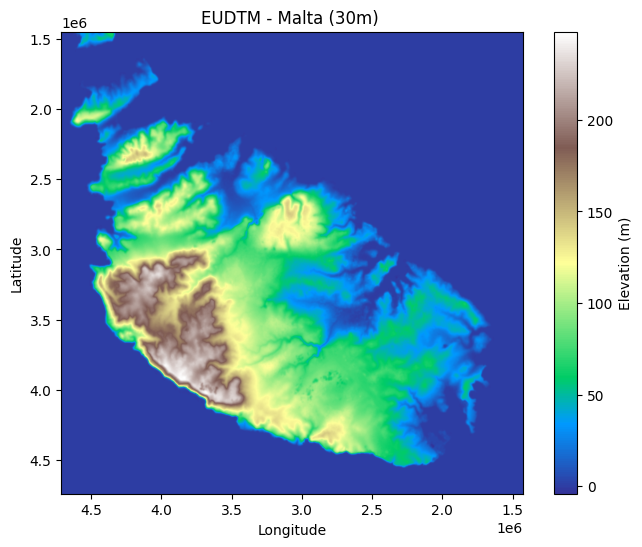

In [10]:
# path to your Copernicus DEM GeoTIFF
raster_path = "../Data/raster_EUDTM.tif"

# open the raster
raster = rasterio.open(raster_path)

# print metadata to verify
print("DEM info:")
print(f"Bounds: {raster.bounds}")
print(f"Resolution: {raster.res}")
print(f"CRS: {raster.crs}")

# read the first (and only) band
elevation = raster.read(1)

# mask no-data values (these appear as very low or high numbers)
elevation = elevation.astype(float)
elevation[elevation <= -100] = float('nan')

# plot
plt.figure(figsize=(8, 6))
plt.imshow(elevation, cmap="terrain", extent=raster.bounds)
plt.colorbar(label="Elevation (m)")
plt.title("EUDTM - Malta (30m) ")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [6]:
G_bike = ox.graph.graph_from_place("Malta (island)", network_type="bike", simplify=True, retain_all=True)
node_colors = ox.plot.get_node_colors_by_attr(G_bike, "elevation", cmap="viridis")
fig, ax = ox.plot.plot_graph(G_bike, node_color=node_colors, node_size=5, edge_linewidth=0.5)


ValueError: There are no attribute values.

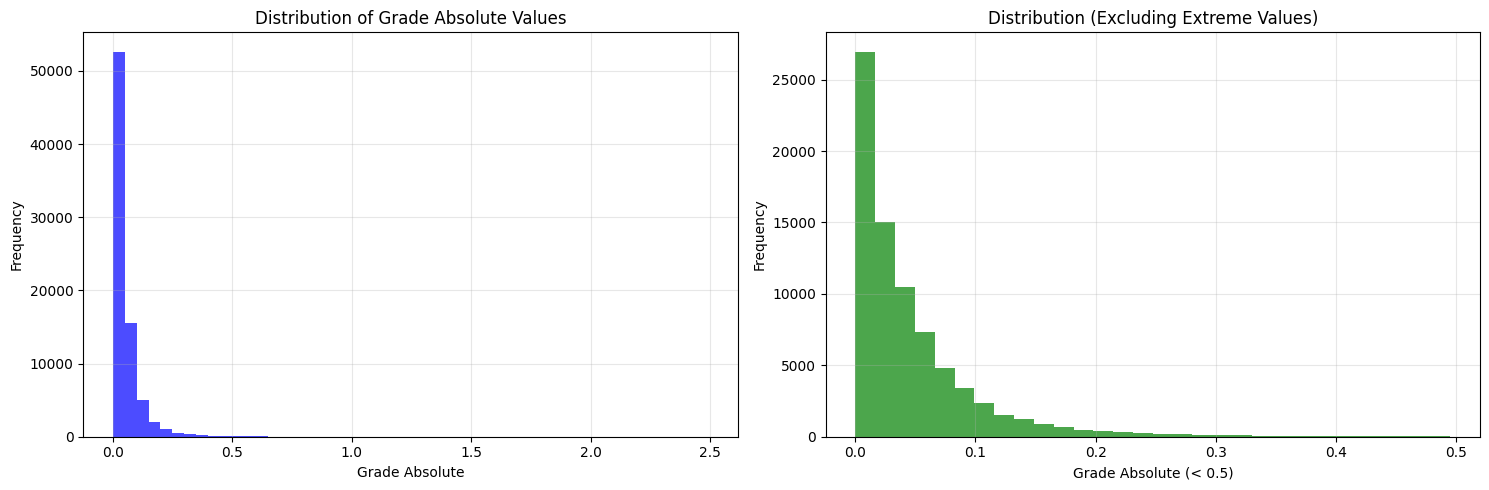

Edges with grade > 50%: 281
Edges with grade > 100%: 54


In [8]:
import matplotlib.pyplot as plt
import numpy as np

G_bike = ox.elevation.add_node_elevations_raster(G_bike, "../Data/rasters_COP30.tif")
G_bike = ox.elevation.add_edge_grades(G_bike, add_absolute=True)

# Get all grade_abs values
grade_abs_values = [data.get("grade_abs", 0) for u, v, k, data in G_bike.edges(keys=True, data=True) if data.get("grade_abs") is not None]

# Create histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of all values
ax1.hist(grade_abs_values, bins=50, alpha=0.7, color='blue')
ax1.set_xlabel('Grade Absolute')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Grade Absolute Values')
ax1.grid(True, alpha=0.3)

# Zoom in on reasonable values (exclude extreme outliers)
reasonable_grades = [g for g in grade_abs_values if g < 0.5]  # Less than 50% grade
ax2.hist(reasonable_grades, bins=30, alpha=0.7, color='green')
ax2.set_xlabel('Grade Absolute (< 0.5)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution (Excluding Extreme Values)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Edges with grade > 50%: {len([g for g in grade_abs_values if g > 0.5])}")
print(f"Edges with grade > 100%: {len([g for g in grade_abs_values if g > 1.0])}")

Reasonable grade range: 0.0000 to 0.4953


C:\Users\Pirot\AppData\Local\Temp\ipykernel_26612\2548623343.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


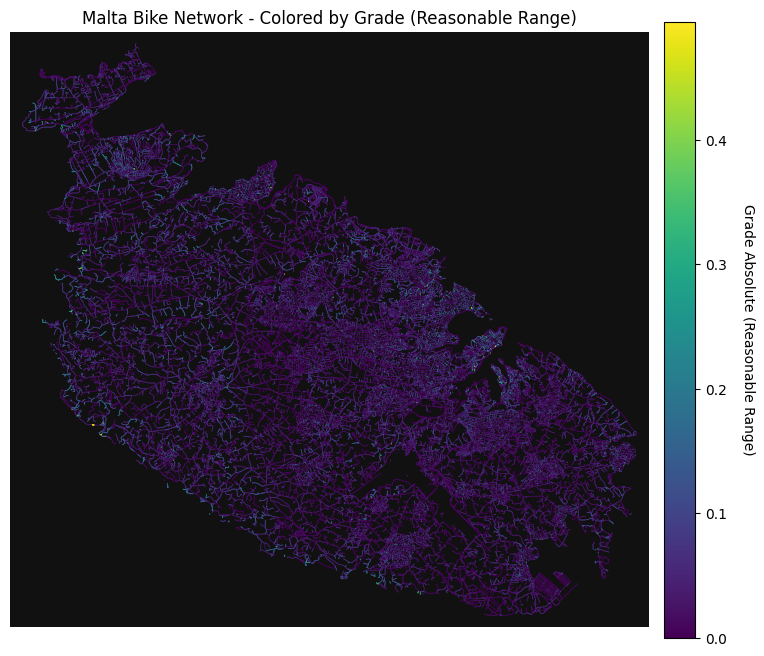

Total edges: 77758
Edges in reasonable range: 77477
Extreme outliers excluded: 281


In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Get all grade_abs values
grade_abs_values = [data.get("grade_abs", 0) for u, v, k, data in G_bike.edges(keys=True, data=True) if data.get("grade_abs") is not None]

# Define reasonable grades range (excluding extreme outliers)
reasonable_grades = [g for g in grade_abs_values if g < 0.5]  # Less than 50% grade
min_reasonable = min(reasonable_grades) if reasonable_grades else 0
max_reasonable = max(reasonable_grades) if reasonable_grades else 0.5

print(f"Reasonable grade range: {min_reasonable:.4f} to {max_reasonable:.4f}")

# Get edge colors based on grade_abs, but constrained to reasonable range
edge_colors = []
for u, v, k, data in G_bike.edges(keys=True, data=True):
    grade = data.get("grade_abs", 0)
    # Clamp extreme values to reasonable range for color mapping
    clamped_grade = np.clip(grade, min_reasonable, max_reasonable)
    edge_colors.append(clamped_grade)

# Create colormap normalization based on reasonable range
norm = plt.Normalize(vmin=min_reasonable, vmax=max_reasonable)
cmap = cm.get_cmap("viridis")

# Convert grades to colors
edge_color_mapped = [cmap(norm(grade)) for grade in edge_colors]

# Plot the network
fig, ax = ox.plot.plot_graph(G_bike, node_size=0, edge_color=edge_color_mapped, 
                            edge_linewidth=0.5, show=False, close=False)

# Add colorbar with reasonable range
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Grade Absolute (Reasonable Range)", rotation=270, labelpad=20)
plt.title("Malta Bike Network - Colored by Grade (Reasonable Range)")
plt.tight_layout()
plt.show()

# Print statistics
print(f"Total edges: {len(grade_abs_values)}")
print(f"Edges in reasonable range: {len(reasonable_grades)}")
print(f"Extreme outliers excluded: {len(grade_abs_values) - len(reasonable_grades)}")

Speed values found:


NameError: name 'cm' is not defined

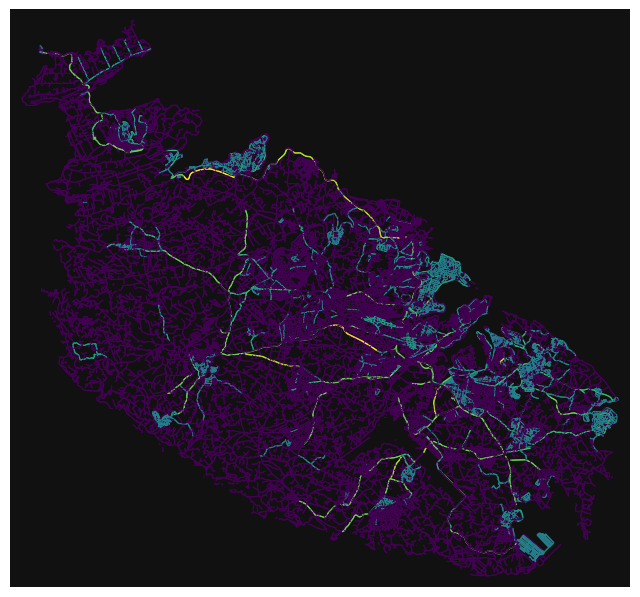

In [ ]:
# First, add maxspeed to useful tags (add this to your imports cell)
from math import ceil, floor


ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["bicycle", "cycleway", "maxspeed"]

# Then reload your network to get speed data
G_bike = ox.graph.graph_from_place("Malta (island)", network_type="bike", simplify=True, retain_all=True)

# Check what speed data you have
speed_values = []
for u, v, k, data in G_bike.edges(keys=True, data=True):
    speed = data.get("maxspeed")
    if speed:
        speed_values.append(speed)

print("Speed values found:")
#print(set(speed_values))

# Function to convert speed strings to numeric values
def extract_speed_numeric(speed_str):
    """Convert speed string to numeric value for plotting"""
    if not speed_str:
        return -10  # Default speed for roads without speed limit
    
    if isinstance(speed_str, list):
        speed_str = speed_str[0]  # Take first speed if multiple
    
    # Remove units and convert to int
    speed_str = str(speed_str).replace(" mph", "").replace(" km/h", "").replace("mph", "").replace("kmh", "")
    
    try:
        return min(int(speed_str),80)
    except:
        return -10  # Default fallback

# Add numeric speed attribute for plotting
for u, v, k, data in G_bike.edges(keys=True, data=True):
    speed_raw = data.get("maxspeed")
    data["speed_numeric"] = extract_speed_numeric(speed_raw)

# Plot colored by speed
edge_colors = ox.plot.get_edge_colors_by_attr(G_bike, "speed_numeric", cmap="viridis")
fig, ax = ox.plot.plot_graph(G_bike, node_size=0, edge_color=edge_colors, edge_linewidth=0.8, show=False, close=False)

# Add colorbar
speed_values = [data.get("speed_numeric", -10) for u, v, k, data in G_bike.edges(keys=True, data=True)]
min_speed = min(speed_values)
max_speed = max(speed_values)

sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=min_speed, vmax=max_speed))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Max Speed (km/h)", rotation=270, labelpad=20)
plt.title("Malta Bike Network - Colored by Max Speed")
plt.tight_layout()
plt.show()

print(f"Speed range: {min_speed} - {max_speed} km/h")
print(f"Roads with speed data: {len([s for s in speed_values if s != -10])}")
print(f"Roads with no speed data: {len([s for s in speed_values if s == -10])}")
print(Counter(speed_values))

In [ ]:
LOCATION = "Malta (island)"
G_bike = ox.graph.graph_from_place(LOCATION, network_type="bike", simplify=True, retain_all=True)
G_drive = ox.graph.graph_from_place(LOCATION, network_type="drive", simplify=True, retain_all=True)

def compare_graph_ids(G_drive, G_bike):
    """Compare node and edge IDs between drive and bike networks"""
    
    # Compare nodes
    drive_nodes = set(G_drive.nodes())
    bike_nodes = set(G_bike.nodes())
    
    common_nodes = drive_nodes.intersection(bike_nodes)
    drive_only_nodes = drive_nodes - bike_nodes
    bike_only_nodes = bike_nodes - drive_nodes
    
    print(f"Drive network nodes: {len(drive_nodes)}")
    print(f"Bike network nodes: {len(bike_nodes)}")
    print(f"Common nodes: {len(common_nodes)}")
    print(f"Drive-only nodes: {len(drive_only_nodes)}")
    print(f"Bike-only nodes: {len(bike_only_nodes)}")
    
    # Compare edges
    drive_edges = set(G_drive.edges(keys=True))
    bike_edges = set(G_bike.edges(keys=True))
    
    common_edges = drive_edges.intersection(bike_edges)
    drive_only_edges = drive_edges - bike_edges
    bike_only_edges = bike_edges - drive_edges
    
    print(f"\nDrive network edges: {len(drive_edges)}")
    print(f"Bike network edges: {len(bike_edges)}")
    print(f"Common edges: {len(common_edges)}")
    print(f"Drive-only edges: {len(drive_only_edges)}")
    print(f"Bike-only edges: {len(bike_only_edges)}")
    
    return {
        'common_nodes': common_nodes,
        'common_edges': common_edges,
        'drive_only_nodes': drive_only_nodes,
        'bike_only_nodes': bike_only_nodes,
        'drive_only_edges': drive_only_edges,
        'bike_only_edges': bike_only_edges
    }

# Test with your graphs
comparison = compare_graph_ids(G_drive, G_bike)

Drive network nodes: 15863
Bike network nodes: 35504
Common nodes: 15499
Drive-only nodes: 364
Bike-only nodes: 20005

Drive network edges: 35675
Bike network edges: 77758
Common edges: 29397
Drive-only edges: 6278
Bike-only edges: 48361


In [ ]:
def compare_road_attributes(G_drive, G_bike, sample_size=10):
    """Compare attributes of common roads between networks"""
    
    # Get common edges
    drive_edges = set(G_drive.edges(keys=True))
    bike_edges = set(G_bike.edges(keys=True))
    common_edges = list(drive_edges.intersection(bike_edges))
    
    # Sample some common edges to check
    import random
    sample_edges = random.sample(common_edges, min(sample_size, len(common_edges)))
    
    print("Comparing road attributes for common edges:")
    print("-" * 60)
    
    for u, v, k in sample_edges:
        print(f"u {u}")
        print(f"v {v}")
        print(f"k {k}")
        drive_data = G_drive[u][v][k]
        bike_data = G_bike[u][v][k]
        
        print(f"\nEdge ({u}, {v}, {k}):")
        print(f"Drive highway: {drive_data.get('highway', 'N/A')}")
        print(f"Bike highway: {bike_data.get('highway', 'N/A')}")
        print(f"Drive name: {drive_data.get('name', 'N/A')}")
        print(f"Bike name: {bike_data.get('name', 'N/A')}")
        print(f"Drive length: {drive_data.get('length', 'N/A')}")
        print(f"Bike length: {bike_data.get('length', 'N/A')}")
        
        # Check if they're the same road
        same_highway = drive_data.get('highway') == bike_data.get('highway')
        same_name = drive_data.get('name') == bike_data.get('name')
        print(f"Same highway type: {same_highway}")
        print(f"Same name: {same_name}")

compare_road_attributes(G_drive, G_bike)

Comparing road attributes for common edges:
------------------------------------------------------------
u 3483885221
v 245552056
k 0

Edge (3483885221, 245552056, 0):
Drive highway: secondary
Bike highway: secondary
Drive name: Triq il-Kbira San Ġużepp
Bike name: Triq il-Kbira San Ġużepp
Drive length: 52.134706124483245
Bike length: 52.134706124483245
Same highway type: True
Same name: True
u 245550165
v 245561655
k 0

Edge (245550165, 245561655, 0):
Drive highway: trunk_link
Bike highway: trunk_link
Drive name: N/A
Bike name: N/A
Drive length: 181.94471494557743
Bike length: 181.94471494557743
Same highway type: True
Same name: True
u 5029126401
v 5029122819
k 0

Edge (5029126401, 5029122819, 0):
Drive highway: residential
Bike highway: residential
Drive name: Triq Ġużè Muscat Azzopardi
Bike name: Triq Ġużè Muscat Azzopardi
Drive length: 17.657144047810853
Bike length: 17.657144047810853
Same highway type: True
Same name: True
u 246156215
v 246156015
k 0

Edge (246156215, 246156015, 

In [ ]:
def verify_spatial_consistency(G_drive, G_bike):
    """Verify that common node IDs have the same coordinates"""
    
    drive_nodes = set(G_drive.nodes())
    bike_nodes = set(G_bike.nodes())
    common_nodes = drive_nodes.intersection(bike_nodes)
    
    mismatched_coordinates = []
    
    for node_id in list(common_nodes)[:100]:  # Check first 100 common nodes
        drive_x = G_drive.nodes[node_id]['x']
        drive_y = G_drive.nodes[node_id]['y']
        bike_x = G_bike.nodes[node_id]['x']
        bike_y = G_bike.nodes[node_id]['y']
        
        # Check if coordinates match (within small tolerance for floating point)
        if abs(drive_x - bike_x) > 1e-6 or abs(drive_y - bike_y) > 1e-6:
            mismatched_coordinates.append(node_id)
    
    print(f"Checked {min(100, len(common_nodes))} common nodes")
    print(f"Nodes with mismatched coordinates: {len(mismatched_coordinates)}")
    
    if mismatched_coordinates:
        print("Sample mismatched nodes:", mismatched_coordinates[:5])
    else:
        print("✅ All checked nodes have consistent coordinates")
    
    return mismatched_coordinates

# Test spatial consistency
mismatched = verify_spatial_consistency(G_drive, G_bike)

Checked 100 common nodes
Nodes with mismatched coordinates: 0
✅ All checked nodes have consistent coordinates


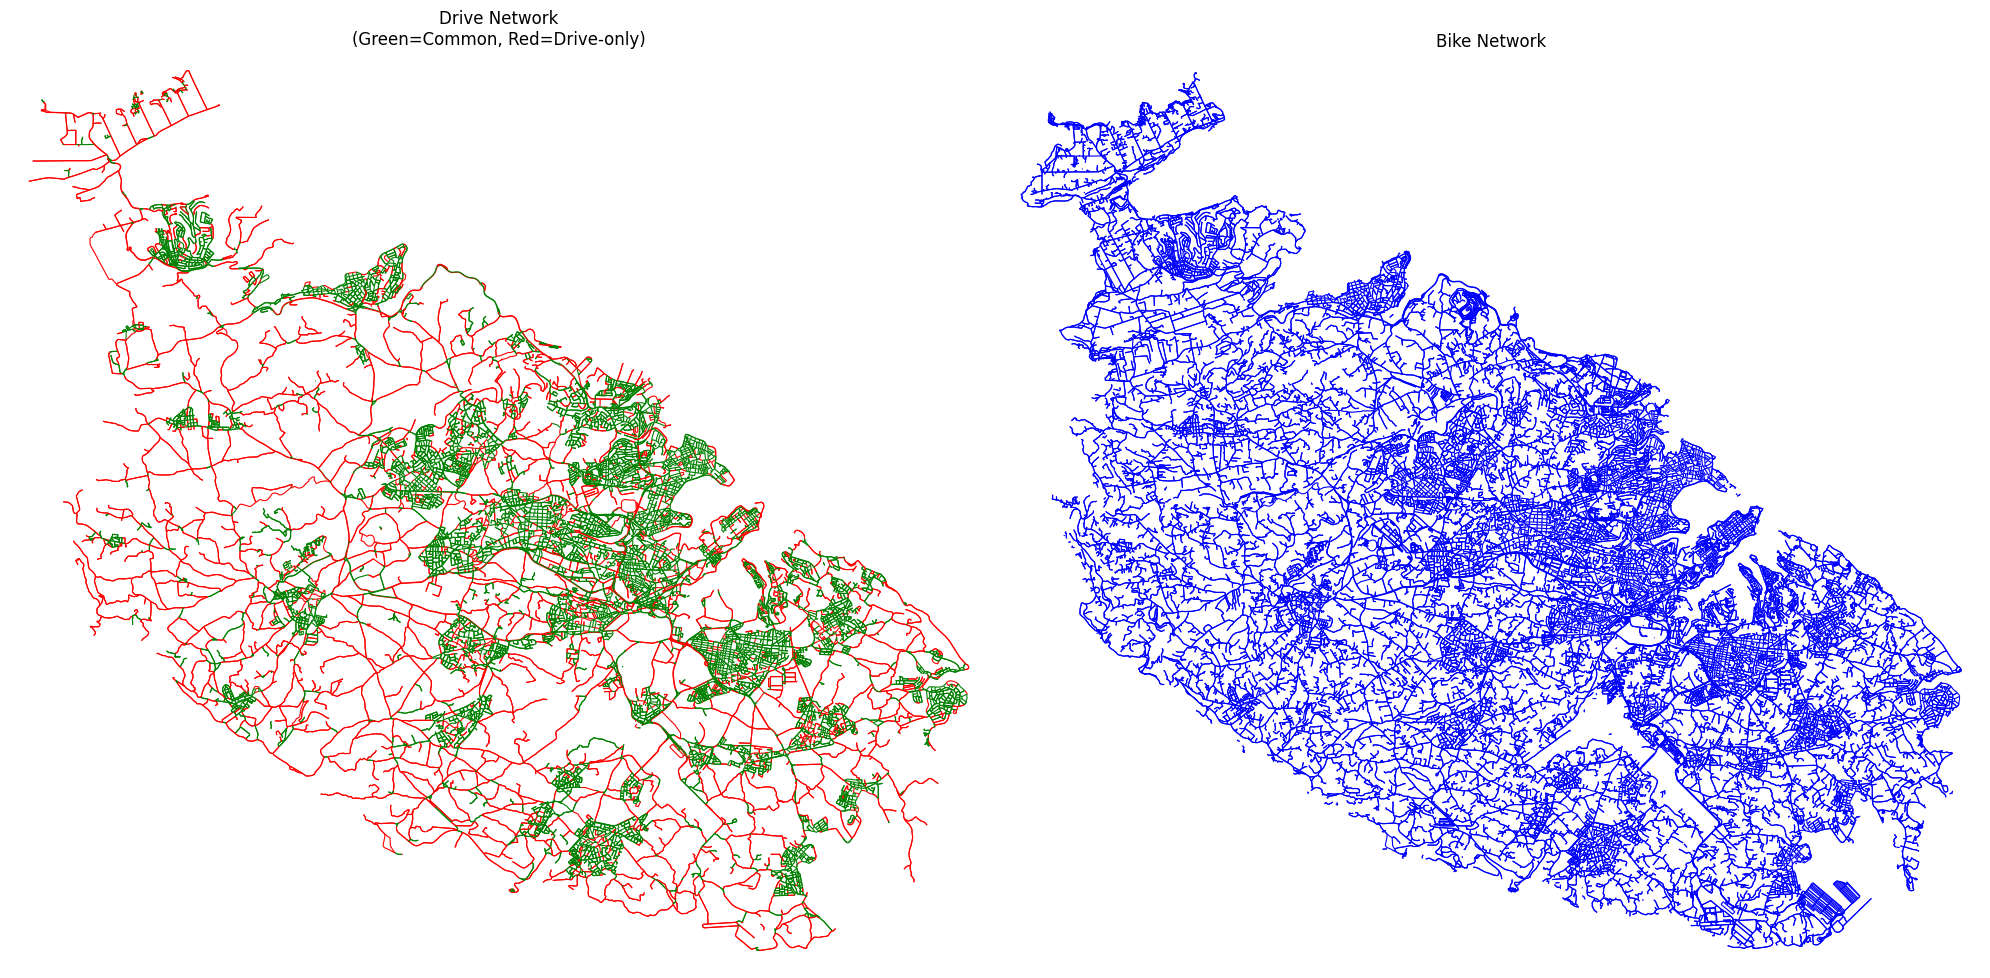

Overlap ratio: 82.4% of drive edges are in bike network


In [ ]:
def visualize_network_overlap(G_drive, G_bike):
    """Visualize which parts of the networks overlap"""
    
    # Get edge sets
    drive_edges = set(G_drive.edges(keys=True))
    bike_edges = set(G_bike.edges(keys=True))
    common_edges = drive_edges.intersection(bike_edges)
    
    # Create color mapping
    edge_colors = []
    for u, v, k, data in G_drive.edges(keys=True, data=True):
        if (u, v, k) in common_edges:
            edge_colors.append("green")  # Common to both
        else:
            edge_colors.append("red")    # Drive only
    
    # Plot drive network with color coding
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Drive network with overlap highlighted
    ox.plot_graph(G_drive, node_size=0, edge_color=edge_colors, 
                  edge_linewidth=0.8, ax=ax1, show=False, close=False)
    ax1.set_title("Drive Network\n(Green=Common, Red=Drive-only)")
    
    # Bike network
    ox.plot_graph(G_bike, node_size=0, edge_color="blue", 
                  edge_linewidth=0.8, ax=ax2, show=False, close=False)
    ax2.set_title("Bike Network")
    
    plt.tight_layout()
    plt.show()
    
    print(f"Overlap ratio: {len(common_edges)/len(drive_edges)*100:.1f}% of drive edges are in bike network")

# Visualize the overlap
visualize_network_overlap(G_drive, G_bike)

In [ ]:
def complete_network_comparison(G_drive, G_bike):
    """Complete comparison between drive and bike networks"""
    
    print("=== NETWORK COMPARISON ANALYSIS ===\n")
    
    # Basic comparison
    comparison = compare_graph_ids(G_drive, G_bike)
    
    # Spatial verification
    print("\n=== SPATIAL CONSISTENCY CHECK ===")
    mismatched = verify_spatial_consistency(G_drive, G_bike)
    
    # Attribute comparison
    print("\n=== ROAD ATTRIBUTE COMPARISON ===")
    compare_road_attributes(G_drive, G_bike, sample_size=5)
    
    # Calculate overlap percentages
    drive_total = len(G_drive.edges())
    bike_total = len(G_bike.edges())
    common_total = len(comparison['common_edges'])
    
    print(f"\n=== SUMMARY ===")
    print(f"Drive→Bike overlap: {common_total/drive_total*100:.1f}%")
    print(f"Bike→Drive overlap: {common_total/bike_total*100:.1f}%")
    
    if len(mismatched) == 0 and common_total > 0:
        print("✅ Networks appear to use consistent IDs for same roads")
    else:
        print("⚠️ Networks may have inconsistent IDs or represent different road sets")

# Run complete analysis
complete_network_comparison(G_drive, G_bike)

=== NETWORK COMPARISON ANALYSIS ===

Drive network nodes: 15863
Bike network nodes: 35504
Common nodes: 15499
Drive-only nodes: 364
Bike-only nodes: 20005

Drive network edges: 35675
Bike network edges: 77758
Common edges: 29397
Drive-only edges: 6278
Bike-only edges: 48361

=== SPATIAL CONSISTENCY CHECK ===
Checked 100 common nodes
Nodes with mismatched coordinates: 0
✅ All checked nodes have consistent coordinates

=== ROAD ATTRIBUTE COMPARISON ===
Comparing road attributes for common edges:
------------------------------------------------------------

Edge (12922667223, 1639213058, 0):
Drive highway: tertiary
Bike highway: tertiary
Drive name: Triq San Nikola
Bike name: Triq San Nikola
Drive length: 17.874995281213476
Bike length: 17.874995281213476
Same highway type: True
Same name: True

Edge (264310275, 264310273, 0):
Drive highway: residential
Bike highway: residential
Drive name: Triq Miġra
Bike name: Triq Miġra
Drive length: 64.77420714533984
Bike length: 64.77420714533984
Sam

In [ ]:
# Get road names for unclassified highways
unclassified_roads = []

for u, v, k, data in G_bike.edges(keys=True, data=True):
    highway = data.get("cycleway")
    
    # Handle list of highway types
    if isinstance(highway, list):
        highway_types = highway
    else:
        highway_types = [highway] if highway else []
    
    # Check if any highway type is unclassified
    if "shared_lane" in highway_types:
        road_name = data.get("name", "Unnamed road")
        road_ref = data.get("ref", "No ref")
        
        # Handle road names that might be lists
        if isinstance(road_name, list):
            road_name = road_name[0] if road_name else "Unnamed road"
        
        # Handle refs that might be lists
        if isinstance(road_ref, list):
            road_ref = road_ref[0] if road_ref else "No ref"
        
        unclassified_roads.append({
            'edge': (u, v, k),
            'name': road_name,
            'ref': road_ref,
            'highway': highway,
            'length': data.get('length', 0)
        })

# Print unique road names
unique_names = set()
for road in unclassified_roads:
    if road['name'] != "Unnamed road":
        unique_names.add(road['name'])  # Now road['name'] is guaranteed to be a string

print(f"Found {len(unclassified_roads)} unclassified road segments")
print(f"Unique named unclassified roads: {len(unique_names)}")
print("\nUnclassified road names:")
for name in sorted(unique_names):
    print(f"  - {name}")

# Show roads without names
unnamed_count = len([r for r in unclassified_roads if r['name'] == "Unnamed road"])
print(f"\nUnnamed unclassified roads: {unnamed_count}")

# Show sample of roads with details
print(f"\nSample unclassified roads with details:")
for i, road in enumerate(unclassified_roads[:10]):
    print(f"{i+1}. {road['name']} (ref: {road['ref']}) - {road['length']:.1f}m")

Found 12 unclassified road segments
Unique named unclassified roads: 1

Unclassified road names:
  - Triq San Ġwann tal-Għargħar

Unnamed unclassified roads: 0

Sample unclassified roads with details:
1. Triq San Ġwann tal-Għargħar (ref: No ref) - 39.5m
2. Triq San Ġwann tal-Għargħar (ref: No ref) - 72.7m
3. Triq San Ġwann tal-Għargħar (ref: No ref) - 161.4m
4. Triq San Ġwann tal-Għargħar (ref: No ref) - 39.5m
5. Triq San Ġwann tal-Għargħar (ref: No ref) - 161.4m
6. Triq San Ġwann tal-Għargħar (ref: No ref) - 16.1m
7. Triq San Ġwann tal-Għargħar (ref: No ref) - 109.5m
8. Triq San Ġwann tal-Għargħar (ref: No ref) - 23.6m
9. Triq San Ġwann tal-Għargħar (ref: No ref) - 23.6m
10. Triq San Ġwann tal-Għargħar (ref: No ref) - 90.4m


# Basic street network stats

In [ ]:
# what sized area does our network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

275524219.5147742

In [ ]:
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 15780,
 'm': 35608,
 'k_avg': 4.513054499366286,
 'edge_length_total': 3321904.9589776746,
 'edge_length_avg': 93.29097278638717,
 'streets_per_node_avg': 2.849619771863118,
 'streets_per_node_counts': {0: 0,
  1: 1898,
  2: 216,
  3: 12072,
  4: 1555,
  5: 33,
  6: 6},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.12027883396704689,
  2: 0.013688212927756654,
  3: 0.7650190114068441,
  4: 0.0985424588086185,
  5: 0.002091254752851711,
  6: 0.00038022813688212925},
 'intersection_count': 13882,
 'street_length_total': 1990686.3459606594,
 'street_segment_count': 22527,
 'street_length_avg': 88.36890602213607,
 'circuity_avg': 1.0706844803490096,
 'self_loop_proportion': 0.0010653882008256758,
 'clean_intersection_count': 8625,
 'node_density_km': 57.27264204863792,
 'intersection_density_km': 50.38395544481569,
 'edge_density_km': 12056.671333024307,
 'street_density_km': 7225.086598435731,
 'clean_intersection_density_km': 31.30396309692662}

# Visualize street centrality

In [ ]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

KeyboardInterrupt: 

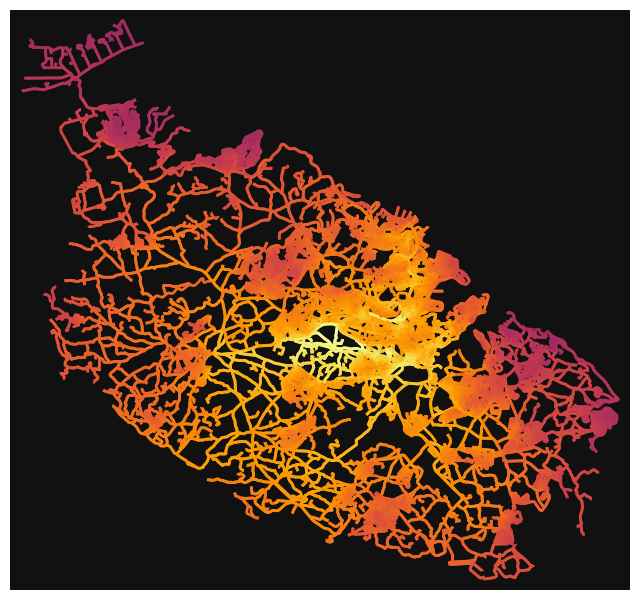

In [ ]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

# Routing

In [ ]:
# impute missing edge speeds and calculate edge travel times with the speed module
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

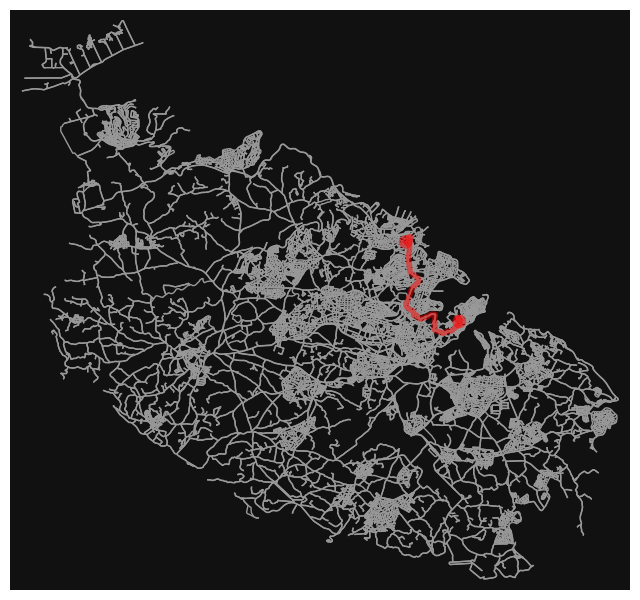

In [ ]:
# get the nearest network nodes to two lat/lng points with the distance module
orig = ox.distance.nearest_nodes(G, X=35.893385, Y=14.477465)
dest = ox.distance.nearest_nodes(G, X=35.890245, Y=14.479616)

orig = next(iter(G))
dest = list(G)[-1]

# find the shortest path between nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [ ]:
# how long is our route in meters?
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
round(sum(edge_lengths))

6951

In [ ]:
# how far is it between these two nodes as the crow flies?
# use OSMnx's vectorized great-circle distance (haversine) function
orig_x = G.nodes[orig]["x"]
orig_y = G.nodes[orig]["y"]
dest_x = G.nodes[dest]["x"]
dest_y = G.nodes[dest]["y"]
round(ox.distance.great_circle(orig_y, orig_x, dest_y, dest_x))

3601

Found 523 edges with parking information

Parking type counts:
none: 35052
lane: 330
no: 155
side_parking: 36
street_side: 2


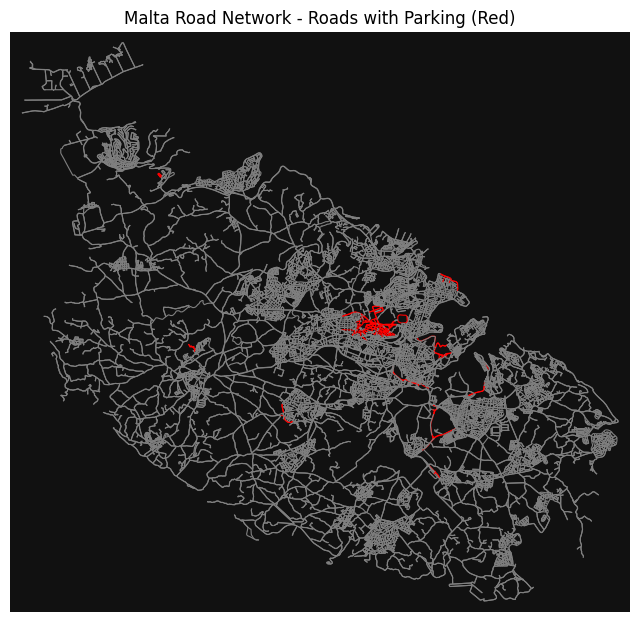

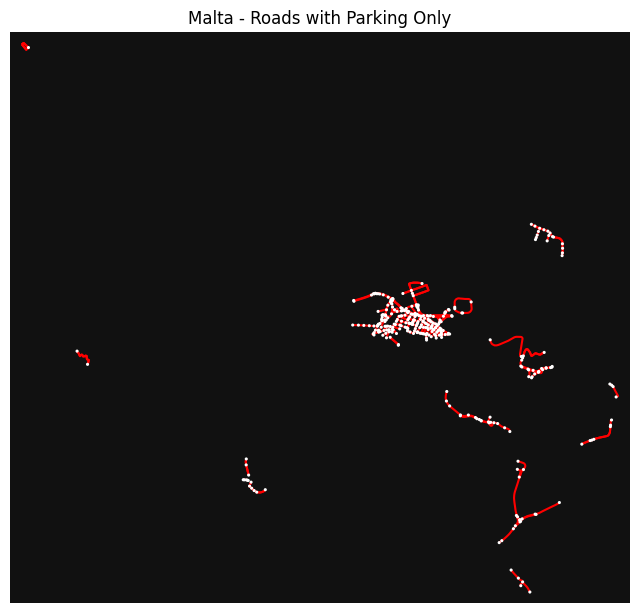

In [ ]:
# Add parking-related tags to OSMnx settings
ox.settings.useful_tags_way = ox.settings.useful_tags_way + ["parking", "parking:lane", "parking:both", "parking:left", "parking:right"]

# Download network with parking data
G = ox.graph_from_place("Malta (island)", network_type="drive")

# Find edges with parking information
parking_edges = []
edge_colors = []
parking_counts = Counter()

for u, v, k, data in G.edges(keys=True, data=True):
    has_parking = False
    parking_type = "none"
    
    # Check various parking tags
    parking = data.get("parking")
    parking_lane = data.get("parking:lane") 
    parking_both = data.get("parking:both")
    parking_left = data.get("parking:left")
    parking_right = data.get("parking:right")
    
    if parking or parking_lane or parking_both or parking_left or parking_right:
        has_parking = True
        parking_type = parking or parking_lane or parking_both or "side_parking"
        
        # Handle case where parking_type is a list
        if isinstance(parking_type, list):
            parking_type = parking_type[0]
        
        parking_edges.append((u, v, k, data))
        edge_colors.append("red")  # Red for roads with parking
    else:
        edge_colors.append("gray")  # Gray for roads without parking
    
    parking_counts[parking_type] += 1

print(f"Found {len(parking_edges)} edges with parking information")
print("\nParking type counts:")
for parking_type, count in parking_counts.most_common():
    print(f"{parking_type}: {count}")

# Plot the network highlighting parking areas
fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors, edge_linewidth=0.8, show=False, close=False)
plt.title("Malta Road Network - Roads with Parking (Red)")
plt.show()

# Create a detailed view of just parking roads
if parking_edges:
    parking_edge_colors = ["red"] * len(parking_edges)
    parking_graph = G.edge_subgraph([(u, v, k) for u, v, k, data in parking_edges])
    fig, ax = ox.plot_graph(parking_graph, node_size=5, edge_color=parking_edge_colors, edge_linewidth=1.5,  show=False, close=False)
    plt.title("Malta - Roads with Parking Only")
    plt.show()